In [ ]:
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense,Conv2D,MaxPooling2D, GRU
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
import io
import scipy.ndimage

In [ ]:
upload =files.upload()
stock_data = pd.read_csv(io.BytesIO(upload['close price.csv']))
stock_data.head()

Saving close price.csv to close price.csv


,Date,Akhaber,Asia,Foulad,Hkashti,Mafakher,Nori,Satran,Shasta,Tejarat
0,20231231,11830,2136,6230,12480,12150,149510,8560,1265,2395
1,20231230,11830,2114,6280,12660,12710,149620,8610,1268,2421
2,20231227,11830,2076,6220,12590,13010,150250,8600,1264,2415
3,20231226,11880,2072,6210,12540,13260,149330,9030,1262,2428
4,20231225,11800,2068,6270,12830,13180,149770,9420,1273,2470


In [ ]:
stock_data = stock_data.sort_values(by='Date', ascending= True)
stock_data.head()

,Date,Akhaber,Asia,Foulad,Hkashti,Mafakher,Nori,Satran,Shasta,Tejarat
882,20200502,10790,19047,9091,30822,36334,97810,12114,12636,1490
881,20200503,11000,19986,9545,32363,38141,102699,12114,13267,1564
880,20200504,11286,19207,10022,31845,36440,99113,12114,13267,1642
879,20200505,11542,18869,10262,30824,36593,94792,11415,14465,1721
878,20200506,11957,17926,10198,29405,35559,97068,11301,14465,1785


In [ ]:
num_columns=stock_data.shape[1]
num_rows=stock_data.shape[0]
raw_prices = np.zeros((num_rows,num_columns-1))
for i in range(1,num_columns,1):
  for j in range(num_rows):
     raw_prices[j,i-1] = stock_data.iloc[j,i]

In [ ]:
def remove_nan_element (vector):
  non_nan_indices = ~np.isnan(vector)
  vector_without_nan = vector[non_nan_indices]
  return vector_without_nan

#Separate the last_60_ for prediction
last_60 =np.zeros((61,9))
for i in range (raw_prices.shape[1]):
 vector_without_nan=(remove_nan_element(raw_prices[:,i]))
 last_60[:,i] = vector_without_nan[-61:]


#Separate the last_60_ for Plt
last_60_plt =np.zeros((60,9))
for i in range (raw_prices.shape[1]):
 vector_without_nan=(remove_nan_element(raw_prices[:,i]))
 last_60_plt[:,i] = vector_without_nan[-60:]

In [ ]:
last_60_new =[]
for i in range(9):
  last_60_new.append([])
  for j in range(60):
    last_60_new[i].append((last_60[j+1,i]- last_60[j,i])/last_60[j,i])

In [ ]:
save_num_column = np.zeros(num_columns-1)
for column_index in range(num_columns-1):
    column_values = raw_prices[:, column_index]
    nan_indices = np.isnan(column_values)
    column_values = column_values[~nan_indices]
    save_num_column[column_index] = len(column_values)

In [ ]:
new_data =[]
for i in range (raw_prices.shape[1]):
 vector_without_nan=(remove_nan_element(raw_prices[:,i]))
 new_data.append(vector_without_nan[:-60])

In [ ]:
Relative_difference = np.zeros((9,822))
for i in range(9):
  for j in range(822):
        Relative_difference[i,j] =(new_data[i][j+1]- new_data[i][j])/new_data[i][j]

In [ ]:
new_data_2 =[]
for i in range(9):
  new_data_2.append([])
  k=0
  for j in range(len(Relative_difference[i])):
    if abs(Relative_difference[i][j]) >= 0.1:
      k+= 1
      j+=1
    else:
      new_data_2[i].append(Relative_difference[i][j])
  print(k)

3
2
4
7
2
4
3
6
1


In [ ]:
def split_to_squenses(data,step,future):
   X, Y = [], []
   for i in range(len(data)-step-future):
     d=i+step
     X.append(data[i:d])
     Y.append(data[d:(d+future)])
   return np.array(X), np.array(Y)

In [ ]:
from random import choices
def bootstraping(xtrain, nboot):
  indexes = []
  length = xtrain.shape[0]
  indices = list(range(1, length))
  for i in range(nboot):
    boot = choices(indices, k = length)
    indexes.append(boot)
  return indexes

In [ ]:
def create_CNN_model(x_train,y_train):
    model = Sequential()
    model.add(Conv1D(filters=32, kernel_size=5, padding='SAME', activation='relu',input_shape=(x_train.shape[1],x_train.shape[2])))
    model.add(MaxPooling1D(pool_size=2, padding='same'))
    model.add(Flatten())
    #model.add(Dense(50, activation='relu'))
    model.add(Dense(60))
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    return model

In [ ]:
!pip install openpyxl

In [ ]:
inds = []
for sh in range(9):
  upload =files.upload()
  inds.append(pd.read_excel(io.BytesIO(upload[f'inds {sh}.xlsx'])))

Saving inds 0.xlsx to inds 0.xlsx


Saving inds 1.xlsx to inds 1.xlsx


Saving inds 2.xlsx to inds 2.xlsx


Saving inds 3.xlsx to inds 3.xlsx


Saving inds 4.xlsx to inds 4.xlsx


Saving inds 5.xlsx to inds 5.xlsx


Saving inds 6.xlsx to inds 6.xlsx


Saving inds 7.xlsx to inds 7.xlsx


Saving inds 8.xlsx to inds 8.xlsx


In [ ]:
history_boot2 = []
prediction_y_not_boot2 = []
history_not_boot2 = []
prediction_y_boot2 = []
model2 = []
modelb2 = []
cntr1 = 0
#inds = []
for index,share in enumerate(new_data_2):
  cntr2 = 0
  print("property",cntr1+1)
  x_train,y_train = split_to_squenses(share,600,60)
  x_train = np.reshape(x_train, (x_train.shape[0],1 , x_train.shape[1]))
  length = len(new_data_2[cntr1])
  x_test = new_data_2[cntr1][(length - 600):length]
  x_test = np.reshape(x_test, (1,1, len(x_test)))
  model2.append(create_CNN_model(x_train,y_train))
  fited = model2[cntr1].fit(x_train, y_train, epochs=100, batch_size=50, shuffle=False,verbose=0)
  history_not_boot2.append(fited)
  yy = model2[cntr1].predict(x_test)
  yy_array = np.array(yy)
  #df_PNB = pd.DataFrame(yy_array)
  #filepath = f'Prediction_not_boot2 {index+1}.xlsx'
  #df_PNB.to_excel(filepath, index=False)
  prediction_y_not_boot2.append(yy)
  modelb2.append([])
  history_boot2.append([])
  prediction_y_boot2.append([])
  #inds.append(bootstraping(x_train, 15))
  for b in range(15):
    print("bootstrap",cntr2+1)
    #x_boot,y_boot = bootstraping(x_train,y_train)
    indx = np.asarray(inds[cntr1])[b,:]
    x_boot = x_train[indx,:]
    y_boot = y_train[indx,:]
    modelb2[cntr1].append(create_CNN_model(x_boot,y_boot))
    fited = modelb2[cntr1][cntr2].fit(x_boot, y_boot, epochs=100, batch_size=50, shuffle=False,verbose=0)
    history_boot2[cntr1].append(fited)
    yy = modelb2[cntr1][cntr2].predict(x_test)
    yy_array = np.array(yy)
    df_PB = pd.DataFrame(yy_array)
    #filepath = f'Prediction2 {index+1}{b+1}.xlsx'
    #df_PB.to_excel(filepath, index=False)
    prediction_y_boot2[cntr1].append(yy)
    cntr2 = cntr2 + 1
  cntr1 = cntr1 + 1

property 1


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
bootstrap 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
bootstrap 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
bootstrap 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
bootstrap 4


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
bootstrap 5


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
bootstrap 6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
bootstrap 7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
bootstrap 8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
bootstrap 9
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
bootstrap 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
bootstrap 11
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
bootstrap 12
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
bootstrap 13
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
bootstrap 14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
bootstrap 15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
property 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
bootstrap 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
bootstrap 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
bootstrap 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
bootstrap 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
bootstrap 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
bootstrap 6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
bootstrap 7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
bootstrap 8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
boot

In [ ]:
M1 = []
M2 = []
for i in range(9):
  M1.append(mean_squared_error(last_60_new[0], prediction_y_not_boot2[i][0]))
  M2.append(mean_absolute_error(last_60_new[0], prediction_y_not_boot2[i][0]))

print(M1)
print(M2)

[0.0010555324843153358, 0.0011561685241758823, 0.0010657313978299499, 0.0013326858170330524, 0.0010461631463840604, 0.0011198981665074825, 0.0014157441910356283, 0.0009181800996884704, 0.0010637223022058606]
[0.02451019175350666, 0.026564786210656166, 0.025056464597582817, 0.02776006981730461, 0.02503143809735775, 0.025446690618991852, 0.027536634355783463, 0.022359026595950127, 0.024709856137633324]


In [ ]:
Mse =[]
Mae =[]
for i in range (9):
  Mse.append([])
  Mae.append([])
  for j in range(15):
     Mse[i].append(mean_squared_error(last_60_new[0], prediction_y_boot2[i][j][0]))
     Mae[i].append(mean_absolute_error(last_60_new[0], prediction_y_boot2[i][j][0]))

In [ ]:
for i in range (9):
   Mean_Mse= np.mean(Mse[i])
   STD_Mse = np.std(Mse[i])
   print(Mean_Mse, STD_Mse)

0.0011170357970210413 0.00010598778074335258
0.0010422914482963582 9.907466637573071e-05
0.0010640949010848999 7.865220227092395e-05
0.0011552540701813996 0.00017779622960114344
0.001245784336545815 0.00019261914509834596
0.0010184586707813045 9.706394350694566e-05
0.0011470391764305532 0.00020671488750279905
0.000936568210211893 7.882872064697498e-05
0.0010408832342363894 0.00011324239190225107


In [ ]:
for i in range (9):
   Mean_Mse= np.mean(Mae[i])
   STD_Mse = np.std(Mae[i])
   print(Mean_Mse, STD_Mse)

0.02597511385877927 0.0014845919723339301
0.02514044816295306 0.0016885788180128873
0.024681363006432852 0.001374654067515107
0.025618909547726314 0.00205111380337916
0.027189115807414056 0.0020733955996295687
0.024388519674539567 0.0015823821403038979
0.025719881678620975 0.00276462461722245
0.023536151523391405 0.0011347019095308455
0.025223286325732865 0.0013550785738773955


In [ ]:
price_prediction_not_boot2 = []
for i in range(9):
    p = np.zeros(60)
    p[0] = new_data[i][822]
    for k in range(1,60):
        p[k] = p[k-1]*(1+prediction_y_not_boot2[i][0][k-1])
    price_prediction_not_boot2.append(p)

In [ ]:
price_prediction2 = []
for i in range(9):
    p = np.zeros((15,60))
    for j in range(15):
        p[j,0] = new_data[i][822]
        for k in range(1,60):
            p[j,k] = p[j,k-1]*(1+prediction_y_boot2[i][j][0][k-1])
    price_prediction2.append(p)

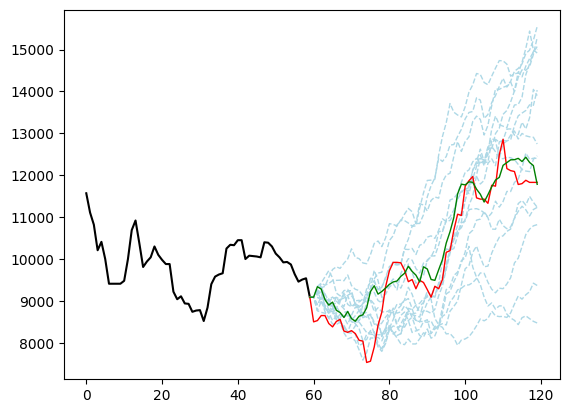

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

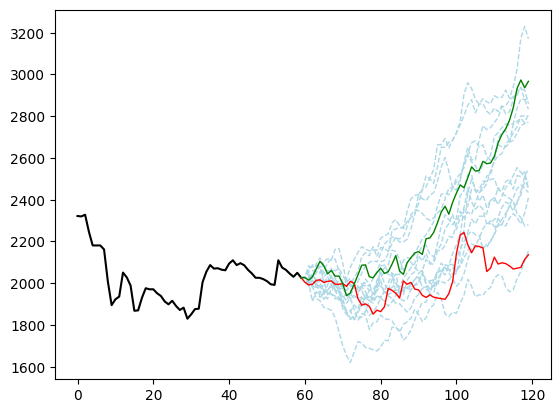

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

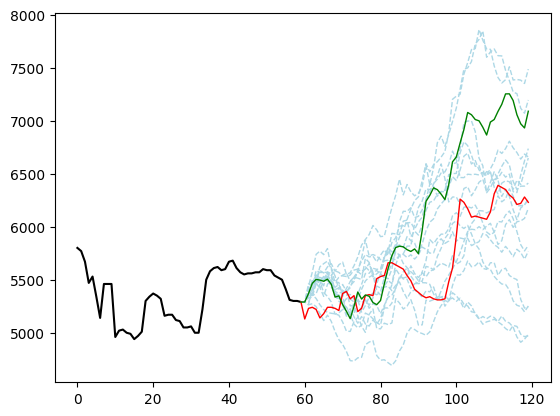

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

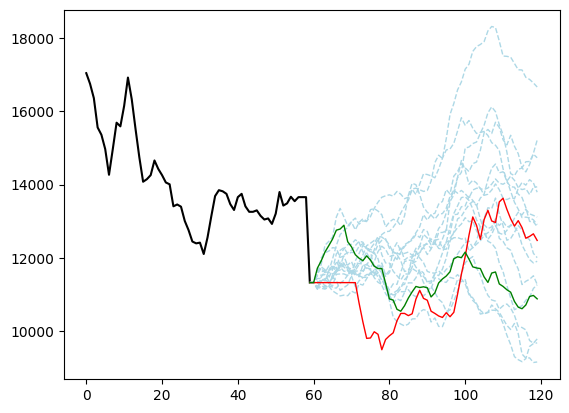

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

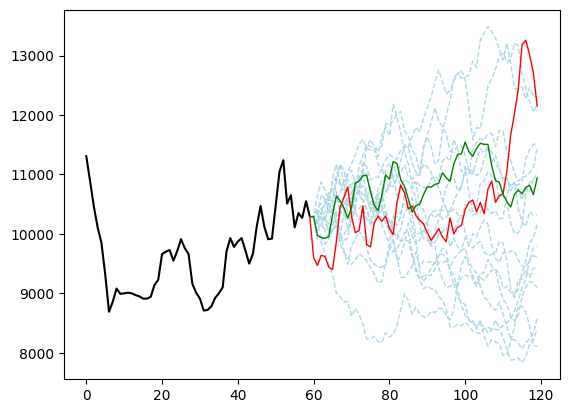

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

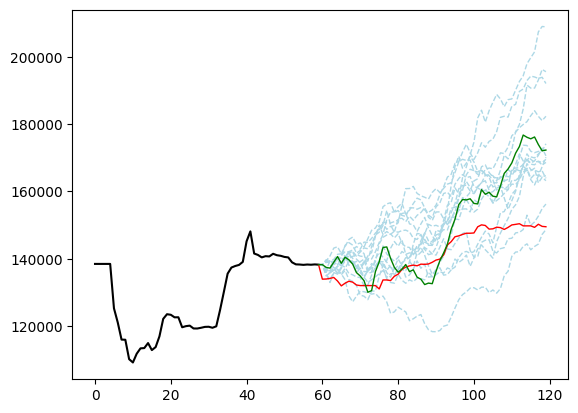

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

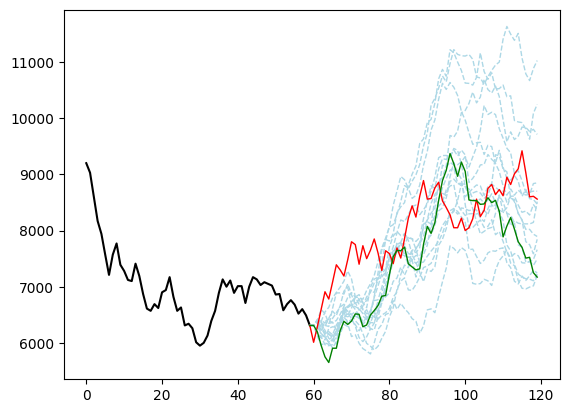

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

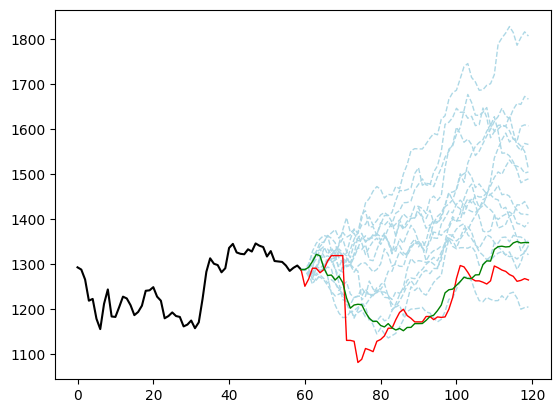

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

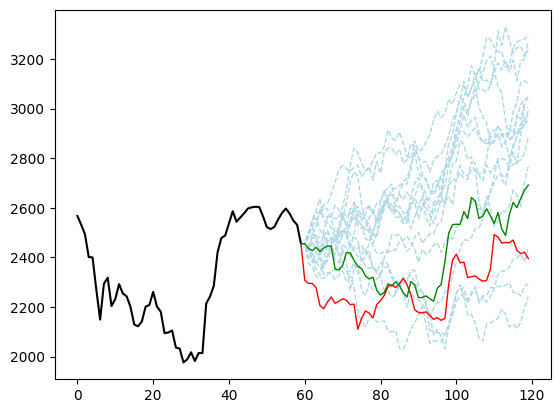

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
for i in range(0,9):
  end = len(new_data[i])
  beg = end - 60
  time = range(len(new_data[i][beg:end]))
  plt.plot(time,new_data[i][beg:end],color="black")
  tim = range(len(new_data[i][beg:end])-1,len(new_data[i][beg:end])+60)
  for j in range(0,15):
    a = np.hstack([new_data[i][end-1],price_prediction2[i][j][:]])
    plt.plot(tim, a, color = 'lightblue', linestyle='dashed', linewidth=1)
  b = np.hstack([new_data[i][end-1],last_60_plt[:,i]])
  plt.plot(tim,b,color = "red", linewidth=1)
  c = np.hstack([new_data[i][end-1],price_prediction_not_boot2[i][:]])
  plt.plot(tim,c,color = "green", linewidth=1)
  plt.savefig(f'stock_c {i+1}.jpg')
  plt.show()
  files.download(f'stock_c {i+1}.jpg')

In [ ]:
def calculate_mean_cov(y_pred):
  mean = np.zeros((15, 9))
  std = np.zeros((15,9))
  for i in range(9):
    for j in range(15):
      mean[j,i] = np.mean(y_pred[i][j])
      std [j,i] = np.std(y_pred[i][j])
  Covariance_Matrix = np.zeros((15,9,9))
  for j in range(15):
    Cov_between = np.array([y_pred[i][j] for i in range(9)])
    CC= Cov_between.reshape(Cov_between.shape[0], Cov_between.shape[2])
    Covariance_Matrix[j,:,:] = np.cov(CC)
  return mean, std, Covariance_Matrix

m2, s2, c2 = calculate_mean_cov(prediction_y_boot2)

In [ ]:
!pip install cvxopt
!pip install scipy

In [ ]:
import numpy as np
from scipy.optimize import minimize , Bounds
from cvxopt import matrix, solvers
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
from google.colab import files
import os
import io
import xlrd

In [ ]:
Mean = m2
covariance_1 = c2[0,:,:]
covariance_2 = c2[1,:,:]
covariance_3 =c2[2,:,:]
covariance_4 = c2[3,:,:]
covariance_5 = c2[4,:,:]
covariance_6 = c2[5,:,:]
covariance_7 = c2[6,:,:]
covariance_8 = c2[7,:,:]
covariance_9 = c2[8,:,:]
covariance_10 = c2[9,:,:]
covariance_11 = c2[10,:,:]
covariance_12 = c2[11,:,:]
covariance_13 = c2[12,:,:]
covariance_14 = c2[13,:,:]
covariance_15 = c2[14,:,:]

In [ ]:
Covariance =[covariance_1, covariance_2,covariance_3, covariance_4, covariance_5, covariance_6, covariance_7, covariance_8, covariance_9, covariance_10, covariance_11, covariance_12, covariance_13, covariance_14, covariance_15]

In [ ]:
MEAN = []
for i in range (15):
  Mean_row =np.zeros((1,9))
  Mean_row[0,:] = Mean[i,:]
  MEAN.append(Mean_row)

In [ ]:
p_2 = 1/15
#Senario_Optimization
Optimal_value =[]
Optimal_solution =[]
for i in range(15):
  sigma = Covariance[i]
  Q = matrix(sigma, tc='d')
  P = matrix(-MEAN[i], tc='d').T
  G = matrix(-np.eye(9), tc='d')
  h = matrix(np.zeros(9), tc='d')
  A = matrix(np.ones(9), tc='d').T
  b = matrix(1.0)
  Optimal_value_Lambda =[]
  Optimal_solution_Lambda =[]
  for Lambda in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]:
    sol = solvers.qp(Lambda*Q,(1-Lambda)*P,G,h,A,b)
    Optimal_value_Lambda.append(sol['primal objective'])
    Optimal_solution_Lambda.append(sol['x'])
  Optimal_value.append(Optimal_value_Lambda)
  Optimal_solution.append(Optimal_solution_Lambda)

     pcost       dcost       gap    pres   dres
 0: -3.1479e-03 -1.0079e+00  1e+00  2e-16  3e+00
 1: -3.1618e-03 -1.7873e-02  1e-02  5e-17  5e-02
 2: -4.0044e-03 -7.9696e-03  4e-03  5e-17  1e-02
 3: -6.5747e-03 -9.2136e-03  3e-03  2e-15  5e-03
 4: -7.7885e-03 -7.8625e-03  7e-05  1e-16  1e-04
 5: -7.8483e-03 -7.8490e-03  7e-07  1e-16  1e-06
 6: -7.8489e-03 -7.8489e-03  7e-09  2e-16  1e-08
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -2.7896e-03 -1.0070e+00  1e+00  2e-16  3e+00
 1: -2.8005e-03 -1.6993e-02  1e-02  1e-16  5e-02
 2: -3.4900e-03 -7.0869e-03  4e-03  1e-16  1e-02
 3: -5.7910e-03 -8.2527e-03  2e-03  4e-16  4e-03
 4: -6.8783e-03 -6.9577e-03  8e-05  3e-16  1e-04
 5: -6.9440e-03 -6.9448e-03  8e-07  2e-16  1e-06
 6: -6.9447e-03 -6.9447e-03  8e-09  1e-16  1e-08
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -2.4328e-03 -1.0061e+00  1e+00  1e-16  3e+00
 1: -2.4412e-03 -1.6113e-02  1e-02  7e-17  5e-02
 2: -2.9898e-03 -6.2050e

In [ ]:
Lambda_list = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for j in range (15):
   print("Bootstrap sample",j+1)
   for i in range(9):
    print("lambda =", Lambda_list[i])
    print(Optimal_solution[j][i][:])

Bootstrap sample 1
lambda = 0.1
[ 3.45e-07]
[ 1.97e-07]
[ 9.34e-08]
[ 9.56e-08]
[ 1.47e-07]
[ 9.23e-08]
[ 1.00e+00]
[ 1.06e-07]
[ 1.82e-07]

lambda = 0.2
[ 4.12e-07]
[ 2.44e-07]
[ 1.20e-07]
[ 1.24e-07]
[ 1.86e-07]
[ 1.02e-07]
[ 1.00e+00]
[ 1.36e-07]
[ 2.29e-07]

lambda = 0.3
[ 4.83e-07]
[ 3.00e-07]
[ 1.56e-07]
[ 1.61e-07]
[ 2.34e-07]
[ 1.09e-07]
[ 1.00e+00]
[ 1.75e-07]
[ 2.86e-07]

lambda = 0.4
[ 5.39e-07]
[ 3.55e-07]
[ 1.96e-07]
[ 2.03e-07]
[ 2.85e-07]
[ 1.13e-07]
[ 1.00e+00]
[ 2.19e-07]
[ 3.44e-07]

lambda = 0.5
[ 5.25e-07]
[ 3.74e-07]
[ 2.23e-07]
[ 2.33e-07]
[ 3.12e-07]
[ 1.15e-07]
[ 1.00e+00]
[ 2.48e-07]
[ 3.73e-07]

lambda = 0.6
[ 2.32e-07]
[ 2.30e-07]
[ 1.76e-07]
[ 1.88e-07]
[ 2.21e-07]
[ 1.28e-07]
[ 1.00e+00]
[ 1.94e-07]
[ 2.54e-07]

lambda = 0.7
[ 2.71e-07]
[ 4.14e-08]
[ 1.29e-07]
[ 1.54e-07]
[ 1.09e-07]
[ 5.16e-05]
[ 1.00e+00]
[ 1.40e-07]
[ 1.30e-07]

lambda = 0.8
[ 1.99e-05]
[ 8.95e-06]
[ 4.66e-06]
[ 4.83e-06]
[ 6.75e-06]
[ 2.48e-01]
[ 7.52e-01]
[ 5.18e-06]
[ 8.81e-06]

lambd

In [ ]:
OPT_X =[]
for l in range(15):
  OX =np.zeros((9,9))
  for n in range(9):
    for k in range(9):
      OX[k,n]=Optimal_solution[l][n][k]
  OPT_X.append(OX)

In [ ]:
#Risk
Lambda_list = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for i in range(15):
  print("Bootstrap sample",i+1)
  sigma = Covariance[i]
  for k in range(9):
    print("Lambda =", Lambda_list[k])
    a = np.dot(OPT_X[i][:,k].T, sigma @ OPT_X[i][:,k])
    print(a)

Bootstrap sample 1
Lambda = 0.1
0.0005785843826946515
Lambda = 0.2
0.0005785840405817598
Lambda = 0.3
0.0005785836401200693
Lambda = 0.4
0.0005785832415619201
Lambda = 0.5
0.0005785830789164434
Lambda = 0.6
0.0005785839918222416
Lambda = 0.7
0.0005785156834695442
Lambda = 0.8
0.00030486461422335497
Lambda = 0.9
0.00014519612217414542
Bootstrap sample 2
Lambda = 0.1
0.00038044850421804435
Lambda = 0.2
0.0003804467935676587
Lambda = 0.3
0.0003804354449281492
Lambda = 0.4
0.0003798900351482216
Lambda = 0.5
0.00029625829446402866
Lambda = 0.6
0.00021611520508012805
Lambda = 0.7
0.0001702803382939903
Lambda = 0.8
0.00012800854967526511
Lambda = 0.9
8.510328295603084e-05
Bootstrap sample 3
Lambda = 0.1
0.0002771429910550482
Lambda = 0.2
0.0002771429454149837
Lambda = 0.3
0.0002771428902285709
Lambda = 0.4
0.00027714282439510944
Lambda = 0.5
0.000277142747480673
Lambda = 0.6
0.0002771426615329155
Lambda = 0.7
0.00027714257927424687
Lambda = 0.8
0.0002771425770086272
Lambda = 0.9
0.00027714168

In [ ]:
#Retern
Lambda_list = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for m in range(15):
  print("Bootstrap sample",m+1)
  for k in range(9):
    print("Lambda =", Lambda_list[k])
    u = np.dot(MEAN[m], OPT_X[m][:,k])
    print(u)

Bootstrap sample 1
Lambda = 0.1
[0.00875315]
Lambda = 0.2
[0.00875315]
Lambda = 0.3
[0.00875314]
Lambda = 0.4
[0.00875314]
Lambda = 0.5
[0.00875314]
Lambda = 0.6
[0.00875314]
Lambda = 0.7
[0.00875306]
Lambda = 0.8
[0.00832203]
Lambda = 0.9
[0.00788001]
Bootstrap sample 2
Lambda = 0.1
[0.00365447]
Lambda = 0.2
[0.00365447]
Lambda = 0.3
[0.00365447]
Lambda = 0.4
[0.00365425]
Lambda = 0.5
[0.00361719]
Lambda = 0.6
[0.00356907]
Lambda = 0.7
[0.00352556]
Lambda = 0.8
[0.00346082]
Lambda = 0.9
[0.00333454]
Bootstrap sample 3
Lambda = 0.1
[0.00918972]
Lambda = 0.2
[0.00918972]
Lambda = 0.3
[0.00918972]
Lambda = 0.4
[0.00918971]
Lambda = 0.5
[0.00918971]
Lambda = 0.6
[0.00918971]
Lambda = 0.7
[0.00918971]
Lambda = 0.8
[0.00918971]
Lambda = 0.9
[0.0091897]
Bootstrap sample 4
Lambda = 0.1
[0.0072567]
Lambda = 0.2
[0.0072567]
Lambda = 0.3
[0.0072567]
Lambda = 0.4
[0.0072567]
Lambda = 0.5
[0.0072567]
Lambda = 0.6
[0.0072567]
Lambda = 0.7
[0.0072567]
Lambda = 0.8
[0.00723173]
Lambda = 0.9
[0.006463

In [ ]:
for m in range(15):
  print("Bootstrap sample",m+1)
  for k in range(9):
    print("Lambda =", Lambda_list[k])
    print(Optimal_value[m][k])

Bootstrap sample 1
Lambda = 0.1
-0.007848903642366284
Lambda = 0.2
-0.006944658311144788
Lambda = 0.3
-0.0060404131049502235
Lambda = 0.4
-0.00513616829875462
Lambda = 0.5
-0.004231924453230883
Lambda = 0.6
-0.0033276826565065403
Lambda = 0.7
-0.0024234371113538832
Lambda = 0.8
-0.0015424594226689445
Lambda = 0.9
-0.0007226624785269312
Bootstrap sample 2
Lambda = 0.1
-0.0032700029156309453
Lambda = 0.2
-0.002885532922260192
Lambda = 0.3
-0.0025010617249509232
Lambda = 0.4
-0.0021165698237896697
Lambda = 0.5
-0.0017345290273322361
Lambda = 0.6
-0.0013627939424006763
Lambda = 0.7
-0.000998070492550129
Lambda = 0.8
-0.0006409605946267511
Lambda = 0.9
-0.000295157968163912
Bootstrap sample 3
Lambda = 0.1
-0.0082568880639644
Lambda = 0.2
-0.007324058745541363
Lambda = 0.3
-0.006391229463035621
Lambda = 0.4
-0.005458400247599969
Lambda = 0.5
-0.00452557114143931
Lambda = 0.6
-0.003592742203057387
Lambda = 0.7
-0.002659913521737148
Lambda = 0.8
-0.00172708526812002
Lambda = 0.9
-0.00079425667

In [ ]:
def objective_function_5(X_0,Lambda,index_Lambda, P):
    X = np.zeros((1,9))
    for j in range(9):
      X[0,j]=X_0[j]
    total_sum = 0
    for i in range(15):
        sigma = Covariance[i]
        mean_matrix = MEAN[i]
        V_s = Optimal_value[i][index_Lambda]
        term1 = np.dot(X, sigma @ X.T)
        term2 = np.dot(mean_matrix, X.T)
        term3 = V_s
        total_sum += p_2*(Lambda*term1 -(1-Lambda)*term2 - term3)**2

    return total_sum

In [ ]:
def constraint_1(s):
    return s[0] + s[1] +s[2] + s[3] + s[4] +s[5] + s[6] + s[7] +s[8]  - 1

In [ ]:
from scipy.optimize import LinearConstraint
linear_constraint = LinearConstraint([[1,1,1,1,1,1,1,1,1]], [1], [1])

In [ ]:
#Problem_5

X_0 = [0,0.3,-1,0.4,0,-0.5,1.1,0.2,0.4]
# constarnt = {'type':'eq', 'fun': constraint_1}
Optimal_solution_5=[]
Optimal_value_5=[]
for i in range(9):
   opt_solution = minimize(objective_function_5,X_0,args=(Lambda_list[i], i, p_2),bounds=Bounds(0,np.inf),constraints=[linear_constraint] , method='trust-constr')
   Optimal_solution_5.append(opt_solution.x)
   Optimal_value_5.append(opt_solution.fun)



print("Optimal solution:", Optimal_solution_5)
print("Optimal value:", Optimal_value_5)

Optimal solution: [array([0.44482347, 0.09226553, 0.01963656, 0.01681122, 0.01268673,
       0.04521471, 0.31543115, 0.01883434, 0.03429629]), array([0.42828264, 0.10209968, 0.02449213, 0.01942507, 0.01552763,
       0.05294369, 0.29456115, 0.0227676 , 0.03990044]), array([0.51896414, 0.03577058, 0.00435621, 0.00358587, 0.00235387,
       0.00957006, 0.41351073, 0.00444894, 0.00743959]), array([0.46715875, 0.08600821, 0.0182742 , 0.01398072, 0.00910612,
       0.03902488, 0.32276524, 0.01696849, 0.02671339]), array([0.45708697, 0.09144104, 0.01925747, 0.0148264 , 0.00905384,
       0.04092755, 0.32037168, 0.01800366, 0.02903137]), array([0.40544224, 0.12470103, 0.0260357 , 0.02000965, 0.01487228,
       0.06068243, 0.28214972, 0.02373126, 0.0423757 ]), array([0.21096207, 0.13339698, 0.06376852, 0.06169017, 0.06580315,
       0.11777659, 0.18278598, 0.06794213, 0.0958744 ]), array([0.16991393, 0.13933216, 0.0961125 , 0.0747406 , 0.03749032,
       0.13641863, 0.14193173, 0.0879474 , 0.1

In [ ]:
#Risk of Problem_5
Risk_5 =[]
for k in range(9):
  print("Lambda =", Lambda_list[k])
  total_sum = 0
  for i in range(15):
    sigma = Covariance[i]
    total_sum = total_sum+ p_2 *np.dot(Optimal_solution_5[k].T, sigma @ Optimal_solution_5[k])
  print(total_sum)
  Risk_5.append(total_sum)
print(Risk_5)

Lambda = 0.1
0.00012615752347816317
Lambda = 0.2
0.00011671087854332179
Lambda = 0.3
0.00017743158913013435
Lambda = 0.4
0.00013455326860978257
Lambda = 0.5
0.0001311875811100804
Lambda = 0.6
0.00010936618152154883
Lambda = 0.7
5.2666693624005705e-05
Lambda = 0.8
4.468044773677694e-05
Lambda = 0.9
3.594806583058584e-05
[np.float64(0.00012615752347816317), np.float64(0.00011671087854332179), np.float64(0.00017743158913013435), np.float64(0.00013455326860978257), np.float64(0.0001311875811100804), np.float64(0.00010936618152154883), np.float64(5.2666693624005705e-05), np.float64(4.468044773677694e-05), np.float64(3.594806583058584e-05)]


In [ ]:
#Retern of Problem_5
Retern_5 =[]
for k in range(9):
  print("Lambda =", Lambda_list[k])
  total_sum = 0
  for i in range(15):
    total_sum = total_sum+ p_2 *np.dot(MEAN[i], Optimal_solution_5[k])
  print(total_sum)
  Retern_5.append(total_sum)

print(Retern_5)

Lambda = 0.1
[0.00497378]
Lambda = 0.2
[0.00488634]
Lambda = 0.3
[0.00534479]
Lambda = 0.4
[0.00505214]
Lambda = 0.5
[0.00502724]
Lambda = 0.6
[0.00483738]
Lambda = 0.7
[0.00388635]
Lambda = 0.8
[0.00374885]
Lambda = 0.9
[0.00312625]
[array([0.00497378]), array([0.00488634]), array([0.00534479]), array([0.00505214]), array([0.00502724]), array([0.00483738]), array([0.00388635]), array([0.00374885]), array([0.00312625])]


In [ ]:
# Sharpe Ratio
for k in range (9): # for  lambda
  Sh_R = Retern_5[k]/ Risk_5[k]
  print("Lambda =", Lambda_list[k])
  print(Sh_R)

Lambda = 0.1
[39.42514982]
Lambda = 0.2
[41.86705213]
Lambda = 0.3
[30.12309307]
Lambda = 0.4
[37.5474869]
Lambda = 0.5
[38.32102188]
Lambda = 0.6
[44.23101601]
Lambda = 0.7
[73.79146451]
Lambda = 0.8
[83.90365755]
Lambda = 0.9
[86.96581009]


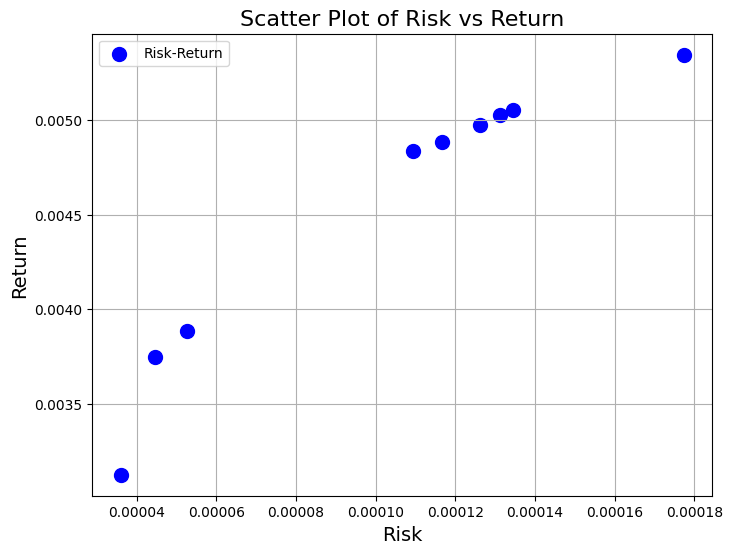

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(Risk_5, Retern_5, color='blue', label='Risk-Return', s=100)
plt.xlabel('Risk', fontsize=14)
plt.ylabel('Return', fontsize=14)
plt.title('Scatter Plot of Risk vs Return', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
pred_nb = np.array(prediction_y_not_boot2).reshape((9,60))
mean =np.mean(pred_nb, axis=1)
mean.shape

(9,)

In [ ]:
covariance_Matrix =np.cov(pred_nb, rowvar=True)
covariance_Matrix.shape

(9, 9)

In [ ]:
#Mean_Variance_Optimization

sigma = covariance_Matrix
P = matrix(sigma, tc='d')
q = - matrix(mean.astype(np.double), tc='d')
G = matrix(-np.eye(9), tc='d')
h = matrix(np.zeros(9), tc='d')
A = matrix(np.ones(9), tc='d').T
b = matrix(1.0)
Optimal_value_Lambda =[]
Optimal_solution_Lambda =[]
for Lambda in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]:
  sol = solvers.qp(Lambda*P,(1-Lambda)*q,G,h,A,b)
  Optimal_value_Lambda.append(sol['primal objective'])
  Optimal_solution_Lambda.append(sol['x'])

     pcost       dcost       gap    pres   dres
 0: -2.6589e-03 -1.0062e+00  1e+00  0e+00  3e+00
 1: -2.6670e-03 -1.6184e-02  1e-02  1e-16  5e-02
 2: -3.1774e-03 -6.2827e-03  3e-03  1e-16  1e-02
 3: -5.2424e-03 -7.4642e-03  2e-03  6e-16  4e-03
 4: -6.1061e-03 -6.1875e-03  8e-05  2e-16  1e-04
 5: -6.1739e-03 -6.1747e-03  8e-07  2e-16  1e-06
 6: -6.1746e-03 -6.1746e-03  8e-09  2e-16  1e-08
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -2.3573e-03 -1.0055e+00  1e+00  0e+00  3e+00
 1: -2.3637e-03 -1.5494e-02  1e-02  7e-17  4e-02
 2: -2.7816e-03 -5.5915e-03  3e-03  1e-16  9e-03
 3: -4.6210e-03 -6.6804e-03  2e-03  1e-15  4e-03
 4: -5.4061e-03 -5.4870e-03  8e-05  1e-16  1e-04
 5: -5.4743e-03 -5.4751e-03  8e-07  1e-18  1e-06
 6: -5.4750e-03 -5.4750e-03  8e-09  1e-16  1e-08
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -2.0567e-03 -1.0048e+00  1e+00  0e+00  3e+00
 1: -2.0615e-03 -1.4804e-02  1e-02  1e-16  4e-02
 2: -2.3939e-03 -4.9006e

In [ ]:
Lambda_list = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for i in range(9):
  print("lambda =", Lambda_list[i])
  print(Optimal_value_Lambda[i])

lambda = 0.1
-0.006174567585945732
lambda = 0.2
-0.005474973230959874
lambda = 0.3
-0.004775379015246776
lambda = 0.4
-0.004075785004035
lambda = 0.5
-0.0033761913193508424
lambda = 0.6
-0.0026765981801279747
lambda = 0.7
-0.001977006043154462
lambda = 0.8
-0.0012774133818717814
lambda = 0.9
-0.0005782281741095746


In [ ]:
Lambda_list = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
X_OPT_No =[]
for i in range(9):
  print("lambda =", Lambda_list[i])
  X = np.zeros(9)
  for j in range(9):
    X[j] = Optimal_solution_Lambda[i][j]
  print(X)
  X_OPT_No.append(X)

lambda = 0.1
[3.61029296e-07 9.99998192e-01 7.00687900e-08 1.43937911e-07
 1.95945595e-07 3.64677231e-07 2.42261774e-07 1.95708125e-07
 2.34420156e-07]
lambda = 0.2
[3.99098868e-07 9.99997955e-01 7.58804932e-08 1.67205017e-07
 2.26672657e-07 4.03450129e-07 2.79269208e-07 2.24679179e-07
 2.69050578e-07]
lambda = 0.3
[4.37060845e-07 9.99997696e-01 8.08081663e-08 1.94652599e-07
 2.62265100e-07 4.41575900e-07 3.21696710e-07 2.57480711e-07
 3.08171319e-07]
lambda = 0.4
[4.70916762e-07 9.99997430e-01 8.39648672e-08 2.26164876e-07
 3.02186798e-07 4.74137657e-07 3.68817333e-07 2.92994429e-07
 3.50537404e-07]
lambda = 0.5
[4.89960336e-07 9.99997207e-01 8.39989509e-08 2.58488241e-07
 3.41769787e-07 4.88131428e-07 4.15329248e-07 3.25577223e-07
 3.89899780e-07]
lambda = 0.6
[4.64602412e-07 9.99997186e-01 7.94066496e-08 2.77814321e-07
 3.62934373e-07 4.48000596e-07 4.41324002e-07 3.35483583e-07
 4.04452608e-07]
lambda = 0.7
[2.86801994e-07 9.99997970e-01 7.11198048e-08 2.28038583e-07
 2.92497824e-0

In [ ]:
#Risking
Risk_No =[]
sigma = covariance_Matrix
for i in range(9):
   print("lambda =", Lambda_list[i])
   print(np.dot(X_OPT_No[i].T, sigma @ X_OPT_No[i]))
   Risk_No.append(np.dot(X_OPT_No[i].T, sigma @ X_OPT_No[i]))

print(Risk_No)

lambda = 0.1
0.00024354789251370958
lambda = 0.2
0.00024354778733792686
lambda = 0.3
0.0002435476719492368
lambda = 0.4
0.00024354755183186185
lambda = 0.5
0.00024354744835720964
lambda = 0.6
0.00024354743090285202
lambda = 0.7
0.00024354776296089432
lambda = 0.8
0.00024354748894652646
lambda = 0.9
0.00022425349410150537
[np.float64(0.00024354789251370958), np.float64(0.00024354778733792686), np.float64(0.0002435476719492368), np.float64(0.00024354755183186185), np.float64(0.00024354744835720964), np.float64(0.00024354743090285202), np.float64(0.00024354776296089432), np.float64(0.00024354748894652646), np.float64(0.00022425349410150537)]


In [ ]:
#Retern
Retern_No =[]
for i in range(9):
  print("lambda =", Lambda_list[i])
  print(np.dot(mean, X_OPT_No[i]))
  Retern_No.append(np.dot(mean, X_OPT_No[i]))

print(Retern_No)

lambda = 0.1
0.0068741610895237965
lambda = 0.2
0.006874160012117084
lambda = 0.3
0.006874158808627371
lambda = 0.4
0.006874157524002285
lambda = 0.5
0.00687415636288029
lambda = 0.6
0.006874156023497076
lambda = 0.7
0.0068741592006359145
lambda = 0.8
0.006874161887251961
lambda = 0.9
0.006791422464552522
[np.float64(0.0068741610895237965), np.float64(0.006874160012117084), np.float64(0.006874158808627371), np.float64(0.006874157524002285), np.float64(0.00687415636288029), np.float64(0.006874156023497076), np.float64(0.0068741592006359145), np.float64(0.006874161887251961), np.float64(0.006791422464552522)]


In [ ]:
# Sharpe Ratio
for k in range (9): # for  lambda
  Sh_R2 = Retern_No[k]/ Risk_No[k]
  print("Lambda =", Lambda_list[k])
  print(Sh_R2)

Lambda = 0.1
28.22508960588457
Lambda = 0.2
28.225097371051316
Lambda = 0.3
28.22510580212061
Lambda = 0.4
28.225114448072972
Lambda = 0.5
28.225121672381494
Lambda = 0.6
28.22512230169691
Lambda = 0.7
28.225096864222383
Lambda = 0.8
28.225139651352592
Lambda = 0.9
30.2845781367334


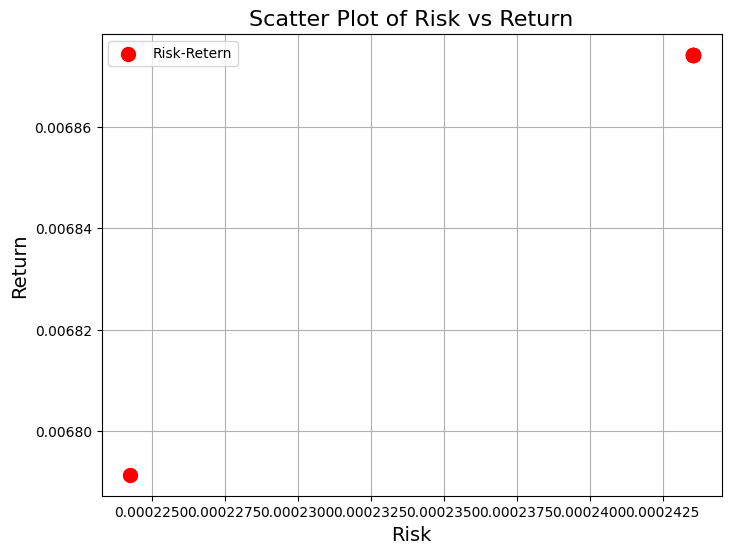

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(Risk_No, Retern_No, color = 'red', label= 'Risk-Retern', s =100)
plt.xlabel('Risk', fontsize=14)
plt.ylabel('Return', fontsize=14)
plt.title('Scatter Plot of Risk vs Return', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
meanr =np.mean(last_60_new, axis=1)
meanr.shape

(9,)

In [ ]:
covariance_Matrixr =np.cov(last_60_new, rowvar=True)
covariance_Matrixr.shape

In [ ]:
#Mean_Variance_Optimization

sigmar = covariance_Matrixr
P = matrix(sigmar, tc='d')
q = -matrix(meanr.astype(np.double), tc='d')
G = matrix(-np.eye(9), tc='d')
h = matrix(np.zeros(9), tc='d')
A = matrix(np.ones(9), tc='d').T
b = matrix(1.0)
Optimal_value_Lambda =[]
Optimal_solution_Lambda =[]
for Lambda in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]:
  sol = solvers.qp(Lambda*P,(1-Lambda)*q,G,h,A,b)
  Optimal_value_Lambda.append(sol['primal objective'])
  Optimal_solution_Lambda.append(sol['x'])

     pcost       dcost       gap    pres   dres
 0: -2.0601e-03 -1.0050e+00  1e+00  2e-16  3e+00
 1: -2.0659e-03 -1.5005e-02  1e-02  5e-17  4e-02
 2: -2.4690e-03 -5.1009e-03  3e-03  2e-16  8e-03
 3: -3.9021e-03 -5.9102e-03  2e-03  9e-16  4e-03
 4: -4.9134e-03 -4.9760e-03  6e-05  2e-16  8e-05
 5: -4.9661e-03 -4.9667e-03  6e-07  6e-19  8e-07
 6: -4.9666e-03 -4.9666e-03  6e-09  1e-20  8e-09
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -1.8182e-03 -1.0044e+00  1e+00  2e-16  3e+00
 1: -1.8228e-03 -1.4437e-02  1e-02  1e-16  4e-02
 2: -2.1498e-03 -4.5301e-03  2e-03  8e-17  8e-03
 3: -3.6039e-03 -5.3527e-03  2e-03  2e-17  4e-03
 4: -4.2941e-03 -4.3706e-03  8e-05  9e-18  1e-04
 5: -4.3601e-03 -4.3608e-03  8e-07  8e-19  1e-06
 6: -4.3607e-03 -4.3607e-03  8e-09  3e-16  1e-08
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -1.5769e-03 -1.0039e+00  1e+00  2e-16  3e+00
 1: -1.5804e-03 -1.3869e-02  1e-02  7e-17  4e-02
 2: -1.8379e-03 -3.9600e

In [ ]:
Lambda_list = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
X_OPT_r =[]
for i in range(9):
  print("lambda =", Lambda_list[i])
  X = np.zeros(9)
  for j in range(9):
    X[j] = Optimal_solution_Lambda[i][j]
  print(X)
  X_OPT_r.append(X)

lambda = 0.1
[2.52191653e-07 1.68552578e-07 4.00099103e-07 2.43718748e-07
 4.69001307e-07 1.88672861e-07 9.99998059e-01 1.12318850e-07
 1.06177055e-07]
lambda = 0.2
[1.90264165e-07 2.79292085e-07 4.80184848e-07 3.53882236e-07
 5.14882743e-07 2.98803115e-07 9.99997468e-01 2.11061170e-07
 2.03762700e-07]
lambda = 0.3
[1.83749862e-07 2.35620587e-07 2.75135728e-07 2.68754867e-07
 2.34375435e-07 2.40600142e-07 9.99998193e-01 1.86606038e-07
 1.82388826e-07]
lambda = 0.4
[1.46016733e-04 2.88963427e-07 1.94725219e-07 2.97120851e-07
 5.94737490e-08 2.70926049e-07 9.99852412e-01 2.30207983e-07
 2.29908086e-07]
lambda = 0.5
[1.37880966e-01 1.47858749e-06 2.77081923e-06 1.86401804e-06
 3.12464881e-06 1.62442267e-06 8.62105942e-01 1.13575766e-06
 1.09449548e-06]
lambda = 0.6
[2.65171340e-01 3.49529479e-06 6.50896697e-06 4.37724309e-06
 7.17025760e-06 3.85285452e-06 7.34798084e-01 2.63268976e-06
 2.53873286e-06]
lambda = 0.7
[3.56116049e-01 1.62623267e-06 3.43657569e-06 2.05045674e-06
 3.96075028e-0

In [ ]:
#Risk
Risk_r =[]
sigmar = covariance_Matrixr
for i in range(9):
   print("lambda =", Lambda_list[i])
   print(np.dot(X_OPT_r[i].T, sigmar @ X_OPT_r[i]))
   Risk_r.append(np.dot(X_OPT_r[i].T, sigmar @ X_OPT_r[i]))

print(Risk_r)

lambda = 0.1
0.0009729716216764105
lambda = 0.2
0.0009729706126233486
lambda = 0.3
0.0009729717989082616
lambda = 0.4
0.0009726804619655211
lambda = 0.5
0.0007339713691429258
lambda = 0.6
0.0005782004123085923
lambda = 0.7
0.0005050848470667473
lambda = 0.8
0.0004710971251508283
lambda = 0.9
0.00042740656552711404
[np.float64(0.0009729716216764105), np.float64(0.0009729706126233486), np.float64(0.0009729717989082616), np.float64(0.0009726804619655211), np.float64(0.0007339713691429258), np.float64(0.0005782004123085923), np.float64(0.0005050848470667473), np.float64(0.0004710971251508283), np.float64(0.00042740656552711404)]


In [ ]:
#Retern
Retern_r =[]
for i in range(9):
  print("lambda =", Lambda_list[i])
  print(np.dot(meanr, X_OPT_r[i]))
  Retern_r.append(np.dot(meanr, X_OPT_r[i]))

print(Retern_r)

lambda = 0.1
0.005572518743175994
lambda = 0.2
0.005572515965781392
lambda = 0.3
0.0055725182212287335
lambda = 0.4
0.005572410793989099
lambda = 0.5
0.005471244344151166
lambda = 0.6
0.005377723167154718
lambda = 0.7
0.00531100970222982
lambda = 0.8
0.005260940717031165
lambda = 0.9
0.005092612115666115
[np.float64(0.005572518743175994), np.float64(0.005572515965781392), np.float64(0.0055725182212287335), np.float64(0.005572410793989099), np.float64(0.005471244344151166), np.float64(0.005377723167154718), np.float64(0.00531100970222982), np.float64(0.005260940717031165), np.float64(0.005092612115666115)]


In [ ]:
# Sharpe Ratio
for k in range (9): # for  lambda
  Sh_R3 = Retern_r[k]/ Risk_r[k]
  print("Lambda =", Lambda_list[k])
  print(Sh_R3)

Lambda = 0.1
5.72731888477349
Lambda = 0.2
5.727321969937642
Lambda = 0.3
5.727317305066258
Lambda = 0.4
5.728922304791423
Lambda = 0.5
7.454302135163741
Lambda = 0.6
9.300794417774584
Lambda = 0.7
10.515084214213154
Lambda = 0.8
11.167422673926955
Lambda = 0.9
11.915147137212257


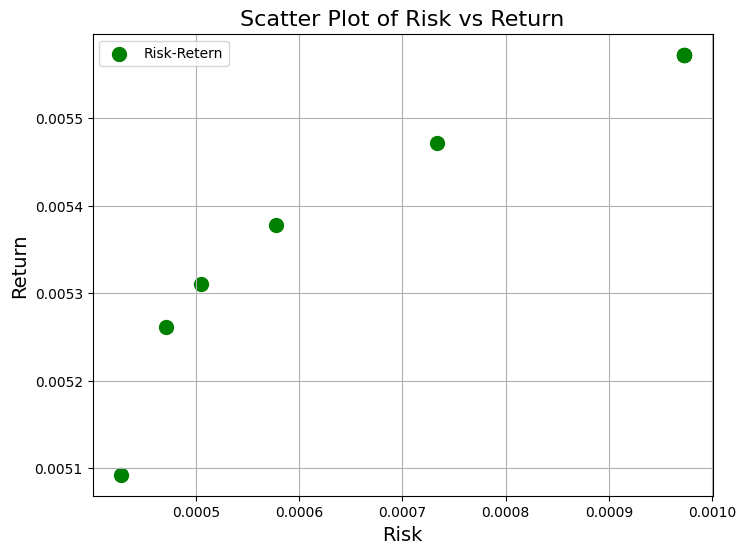

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(Risk_r, Retern_r, color = 'green', label= 'Risk-Retern', s =100)
plt.xlabel('Risk', fontsize=14)
plt.ylabel('Return', fontsize=14)
plt.title('Scatter Plot of Risk vs Return', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
[sum(abs(Optimal_solution_5[i]-X_OPT_r[i])) for i in range(9)]

[np.float64(1.3691338132374526),
 np.float64(1.4108726430361642),
 np.float64(1.1729749171537276),
 np.float64(1.3541743508827864),
 np.float64(1.0834685151216112),
 np.float64(0.9052967241374101),
 np.float64(1.2124735531118727),
 np.float64(1.3762864984922538),
 np.float64(1.4632014033772334)]

In [ ]:
[sum(abs(X_OPT_No[i]-X_OPT_r[i])) for i in range(9)]

[np.float64(1.9999970397458657),
 np.float64(1.9999961355787794),
 np.float64(1.9999962790032697),
 np.float64(1.9999955413137356),
 np.float64(1.999991456515031),
 np.float64(1.9999873813733315),
 np.float64(1.9999926877460752),
 np.float64(1.999993165625459),
 np.float64(1.9056981542094398)]